# Issues
- For vertical levels, sigma-level approximation is used instead of the true hybrid level coordinate system. Pressure levels defined by sigma values are calculated as$$p_{\text{level}} = \sigma_{\text{level}} * p_{\text{surface}}$$ and these $\sigma_{\text{level}}$ are retrieved from [this FAQ page](https://rapidrefresh.noaa.gov/faq/HRRR.faq.html). However, I suspect that this source is outdated as StormCast documentation refers to HRRR's vertical coordinate system as **hybrid** levels and section 2.1 of [this documentation](https://opensky.ucar.edu/islandora/object/technotes%3A576) of Advanced Research WRF model v4 describes a hybrid level system that I suspect HRRR v4 (the latest version) also uses. Anyway I couldn't find a source for the parameters corresponding to each level in the hybrid system so the sigma levels are used as a first attempt approximation.

- HRRR uses Lambert Conformal Grid. However my conversion from ERA5's lat/lon grid to HRRR-format input just bilinearly interpolates the ERA5 grid (something like a spherical coordinate grid) to the required resolution. Again, suitable for a first approximation.

- Some functions are designed to handle multiple initialisation times while others are designed to only handle one (ie assumes that `len(times)==1`). Just stick to one initialisation time for now – I don't quite get the purpose of multiple initialisation times yet.

- `refc` is approximated from total cloud rain water, `tcrw`. As this is not a good approximation, plots of truth vs forecast are given but RMSE and bias is not computed to emphasise that those diagnostics would be unphysical.

- Consider a separate `.py` file for the plotting functions.

# Setup

In [2]:
# ── 0. Install & imports ──────────────────────────────────────────────────────

!pip install -q earth2studio[stormcast]

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import earth2studio.run as run

import utils as ut
import importlib
importlib.reload(ut)

from earth2studio.models.px import StormCast
from earth2studio.data import GFS_FX
from earth2studio.io import ZarrBackend

from google.colab import drive

from pathlib import Path

# ── 1. Configuration ──────────────────────────────────────────────────────────

N_STEPS = 12

# File paths
PATH_SURFACE  = "/content/surface.nc"
PATH_PRESSURE = "/content/pressure.nc"
PATH_OUTPUT   = f"stormcast_output_era5_{N_STEPS}h.zarr"

drive.mount("/content/drive")

# ── 2. Model & coordinate setup ───────────────────────────────────────────────

package = StormCast.load_default_package()
model   = StormCast.load_model(package, conditioning_data_source=GFS_FX())

coords    = model.input_coords()
VARIABLES = list(coords["variable"])
HRRR_Y    = np.asarray(coords["hrrr_y"])
HRRR_X    = np.asarray(coords["hrrr_x"])
NY, NX    = len(HRRR_Y), len(HRRR_X)

# —— 3. Helper functions to build input/truth arrays ———————————————————————————

def build_stormcast_input():
    """
    Construct the full StormCast input array:
        (time, variable, hrrr_y, hrrr_x) = (1, 99, NY, NX)
    """

    with xr.open_dataset(PATH_SURFACE) as ds_surface, xr.open_dataset(PATH_PRESSURE) as ds_pressure:

        ut.validate_era5_pair(ds_surface, ds_pressure)

        start_time = np.datetime64(ds_surface.valid_time.values[0], "ns")
        grid = ut.make_grid(ds_surface, HRRR_Y, HRRR_X)

        data = xr.DataArray(
            np.zeros((1, len(VARIABLES), NY, NX), dtype=np.float32),
            dims=["time", "variable", "hrrr_y", "hrrr_x"],
            coords={
                "time": [start_time],
                "variable": VARIABLES,
                "hrrr_y": HRRR_Y,
                "hrrr_x": HRRR_X,
            },
        )

        ut.fill_surface_fields(data, ds_surface, grid, time_index=0, time_value=start_time, verbose=True)
        sp = ut.get_surface_pressure(ds_surface, grid, time_index=0, verbose=True)
        ut.fill_hybrid_fields(data, ds_pressure, sp, grid, time_index=0, time_value=start_time, verbose=True)
        ut.fill_refc(data, ds_surface, grid, time_index=0, time_value=start_time)

    return data, grid.target_lats, grid.target_lons, start_time

def build_era5_truth(
    valid_time,
    variables=VARIABLES,
    hrrr_y=HRRR_Y,
    hrrr_x=HRRR_X,
    ny=NY,
    nx=NX,
    path_surface=PATH_SURFACE,
    path_pressure=PATH_PRESSURE,
):
    """
    Build ERA5 truth only for requested variables:
        (variable, hrrr_y, hrrr_x)
    """

    variables = list(variables)

    requested = set(variables)
    needs_surface = bool(requested & ut.STORMCAST_SURFACE_VARS)
    needs_pressure = bool(requested - ut.STORMCAST_SURFACE_VARS)

    with xr.open_dataset(path_surface) as ds_surface:

        valid_time = np.datetime64(valid_time, "ns")
        available_times = ds_surface.valid_time.values.astype("datetime64[ns]")

        if valid_time not in available_times:
            raise ValueError(
                f"{valid_time} not found in ERA5 file. "
                f"Available range: {available_times[0]} to {available_times[-1]}"
            )

        time_index = int(np.where(available_times == valid_time)[0][0])

        grid = ut.make_grid(ds_surface, HRRR_Y, HRRR_X)

        truth = xr.DataArray(
            np.zeros((len(variables), ny, nx), dtype=np.float32),
            dims=["variable", "hrrr_y", "hrrr_x"],
            coords={
                "variable": variables,
                "hrrr_y": hrrr_y,
                "hrrr_x": hrrr_x,
            },
        )

        if needs_surface:
            ut.fill_surface_fields(truth, ds_surface, grid, time_index=time_index, time_value=None, verbose=False)

            if "refc" in variables:
                ut.fill_refc(truth, ds_surface, grid, time_index=time_index, time_value=None)

        if needs_pressure:
            with xr.open_dataset(path_pressure) as ds_pressure:
                sp = ut.get_surface_pressure(ds_surface, grid, time_index=time_index, verbose=False)
                ut.fill_hybrid_fields(truth, ds_pressure, sp, grid, time_index=time_index, time_value=None, verbose=False)

    return truth

Mounted at /content/drive


# Execution

In [3]:
# ── 4. Build input array ──────────────────────────────────────────────────────

print("Building StormCast input...")
data, target_lats, target_lons, STARTING_TIME = build_stormcast_input()

print("Validating forecast window...")

with xr.open_dataset(PATH_SURFACE) as ds_surface:
    ut.validate_forecast_window(
        ds_surface,
        start_time=STARTING_TIME,
        nsteps=N_STEPS,
        require_gfs_fx_time=True,
    )

print("Validating StormCast input array...")
ut.validate_stormcast_input_array(data, VARIABLES, NY, NX)



# ── 5. Wrap and sanity-check ──────────────────────────────────────────────────

my_data = ut.MyLocalData(data)
sample = my_data([STARTING_TIME], VARIABLES)

print(f"Earth2Studio wrapper verified: {sample.dims} {sample.shape}")

Building StormCast input...
  t2m  → t2m   | min=289.10  max=307.95
  u10  → u10m  | min=-17.01  max=19.29
  v10  → v10m  | min=-23.24  max=15.18
  msl  → mslp  | min=99177.68  max=101707.47

  sp          | min=82658.1  max=101967.5  mean=100089.9 Pa

Regridding ERA5 pressure-level variables...
  u pressure levels regridded
  v pressure levels regridded
  t pressure levels regridded
  q pressure levels regridded
  z pressure levels regridded
Validating forecast window...
Validating StormCast input array...
Filled 99/99 variables ([] left as zero)
Earth2Studio wrapper verified: ('time', 'variable', 'hrrr_y', 'hrrr_x') (1, 99, 512, 640)


In [ ]:
# ── 6. Inference ──────────────────────────────────────────────────────────────
io = ZarrBackend(PATH_OUTPUT, backend_kwargs={"overwrite": True})
io = run.deterministic(time=[STARTING_TIME], nsteps=N_STEPS, prognostic=model, data=my_data, io=io)

In [3]:
# save inference .zarr file to MyDrive

!du -sh "{PATH_OUTPUT}"              # check total size of the .zarr folder
!find "{PATH_OUTPUT}" -type f | wc -l # counts number of files inside the .zarr folder

!cp -r "{PATH_OUTPUT}" /content/drive/MyDrive/

du: cannot access 'stormcast_output_era5_12h.zarr': No such file or directory
find: ‘stormcast_output_era5_12h.zarr’: No such file or directory
0
cp: cannot stat 'stormcast_output_era5_12h.zarr': No such file or directory


# Comparison

In [4]:
# ── 7. Open forecast output ───────────────────────────────────────────────────

# importing a forecast I generated previously so I don't have to run the 15-min long inference
ds_out = xr.open_zarr("/content/drive/MyDrive/Colab Notebooks/stormcast_output_era5_12h.zarr")
ut.validate_forecast_output(ds_out, N_STEPS)

# ── 8. Verification setup ─────────────────────────────────────────–────────────

VERIFY_VARS = ["t2m", "mslp", "u10m", "v10m", "t5hl", "q5hl", "Z5hl"]

# refc is qualitative only because ERA5 does not provide true composite reflectivity.
PANEL_VARS = VERIFY_VARS + ["refc"]

LEADS_TO_PANEL = sorted(set([0, 1, N_STEPS // 2, N_STEPS]))

SAVE_DIR = Path("verification_panels")
SAVE_DIR.mkdir(exist_ok=True)

In [5]:
# ── 9. Compute verification metrics ────────────────────────────────–───────────

df_metrics = ut.compute_verification_metrics(
    ds_out=ds_out,
    start_time=STARTING_TIME,
    variables=VERIFY_VARS,
    truth_builder=build_era5_truth,
)

df_metrics

Verifying lead 0h, valid_time=2025-11-27 06:00:00
Verifying lead 1h, valid_time=2025-11-27 07:00:00
Verifying lead 2h, valid_time=2025-11-27 08:00:00
Verifying lead 3h, valid_time=2025-11-27 09:00:00
Verifying lead 4h, valid_time=2025-11-27 10:00:00
Verifying lead 5h, valid_time=2025-11-27 11:00:00
Verifying lead 6h, valid_time=2025-11-27 12:00:00
Verifying lead 7h, valid_time=2025-11-27 13:00:00
Verifying lead 8h, valid_time=2025-11-27 14:00:00
Verifying lead 9h, valid_time=2025-11-27 15:00:00
Verifying lead 10h, valid_time=2025-11-27 16:00:00
Verifying lead 11h, valid_time=2025-11-27 17:00:00
Verifying lead 12h, valid_time=2025-11-27 18:00:00


,lead_idx,lead_hour,valid_time,variable,rmse,bias,mae,unit
0,0,0,2025-11-27 06:00:00,t2m,0.000000,0.000000,0.000000,K
1,0,0,2025-11-27 06:00:00,mslp,0.000000,0.000000,0.000000,Pa
2,0,0,2025-11-27 06:00:00,u10m,0.000000,0.000000,0.000000,m/s
3,0,0,2025-11-27 06:00:00,v10m,0.000000,0.000000,0.000000,m/s
4,0,0,2025-11-27 06:00:00,t5hl,0.000000,0.000000,0.000000,K
...,...,...,...,...,...,...,...,...
86,12,12,2025-11-27 18:00:00,u10m,7.298445,1.746253,5.243507,m/s
87,12,12,2025-11-27 18:00:00,v10m,6.104968,-0.570418,5.035250,m/s
88,12,12,2025-11-27 18:00:00,t5hl,15.682785,-6.290154,12.836652,K
89,12,12,2025-11-27 18:00:00,q5hl,0.009351,-0.005547,0.007673,kg/kg


Saved: error_curves/t2m_error_curve.png


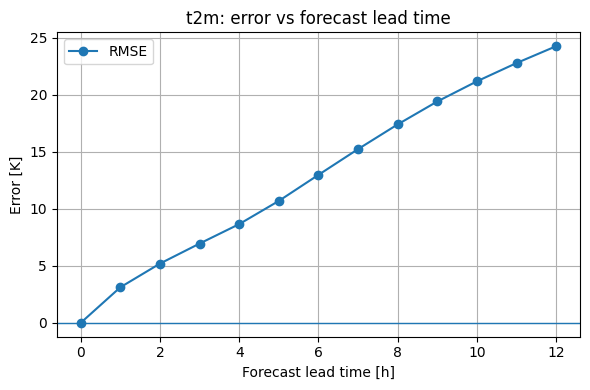

Saved: error_curves/mslp_error_curve.png


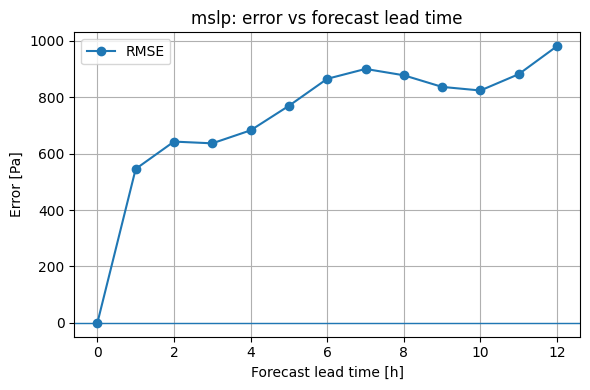

Saved: error_curves/u10m_error_curve.png


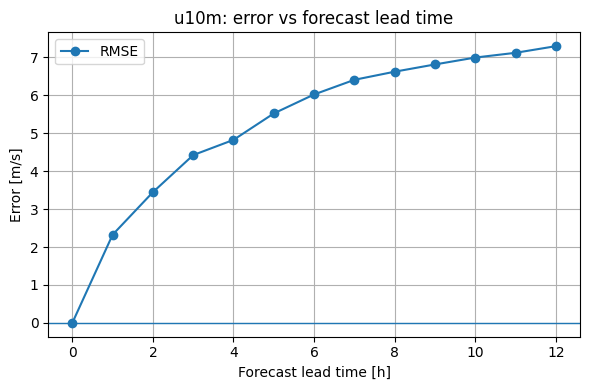

Saved: error_curves/v10m_error_curve.png


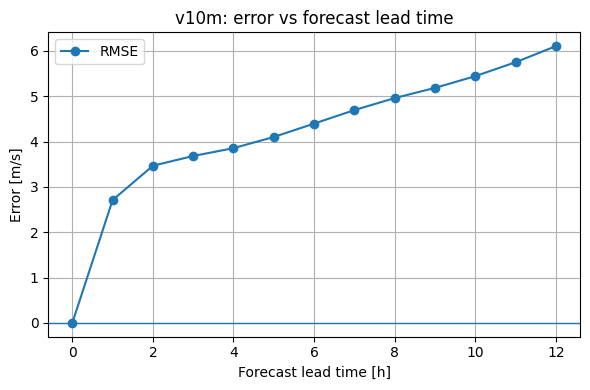

Saved: error_curves/t5hl_error_curve.png


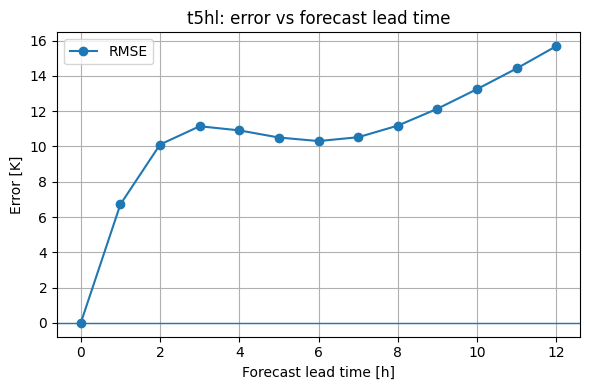

Saved: error_curves/q5hl_error_curve.png


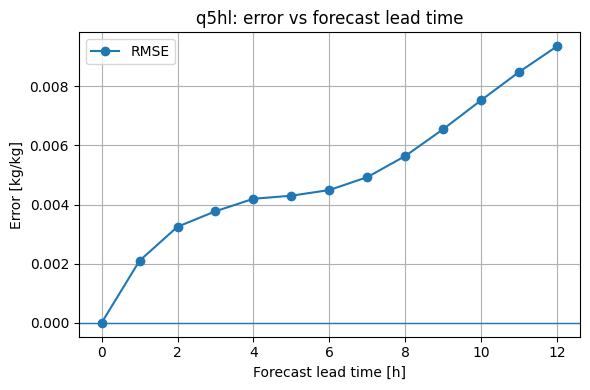

Saved: error_curves/Z5hl_error_curve.png


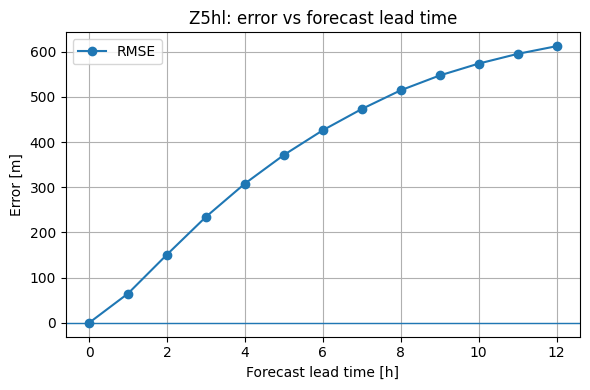

In [10]:
# ── 10. Plot RMSE vs forecast time error curves ───────────────────────────────

ERROR_CURVE_DIR = Path("error_curves")
ERROR_CURVE_DIR.mkdir(exist_ok=True)

ut.plot_error_curves(
    df_metrics=df_metrics,
    variables=VERIFY_VARS,
    metrics=("rmse",),
    save_dir=ERROR_CURVE_DIR,
)

In [7]:
# ── 11. Build truth cache for visual panels ───────────────────────────────────

truth_cache = ut.build_truth_cache(
    ds_out=ds_out,
    start_time=STARTING_TIME,
    variables=PANEL_VARS,
    leads=LEADS_TO_PANEL,
    truth_builder=build_era5_truth,
)

Building panel truth for lead 0h, valid_time=2025-11-27 06:00:00
Building panel truth for lead 1h, valid_time=2025-11-27 07:00:00
Building panel truth for lead 6h, valid_time=2025-11-27 12:00:00
Building panel truth for lead 12h, valid_time=2025-11-27 18:00:00


In [8]:
# ── 12. Generate verification panels ──────────────────────────────────────────

for var in PANEL_VARS:
    ut.plot_forecast_truth_error_panel(
        var=var,
        leads_to_plot=LEADS_TO_PANEL,
        ds=ds_out,
        truth_cache=truth_cache,
        df_metrics=df_metrics,
        save_dir=SAVE_DIR,
    )

Output hidden; open in https://colab.research.google.com to view.